# Tech Stock Analysis and Prediction
## Linear Regression Model

**Goal:** Build a Linear Regression model to predict next day returns of NVDA stock
as a simple baseline for comparison with more complex ensemble methods.

**Input:** Cleaned data with engineered features

**Output:** Baseline model performance metrics

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')


#  Loading Data

Loading the cleaned NVDA dataset containing daily stock prices and returns from 2018-2025.

In [3]:
# load cleaned data
nvda = pd.read_csv(r'../data/nvda_cleaned.csv')
nvda['date'] = pd.to_datetime(nvda['date'])
nvda = nvda.sort_values('date').reset_index(drop=True)
print(nvda.shape)
print(nvda.head())

(1989, 6)
        date Stock  Adj Close   Returns  Rolling Std    Growth
0 2018-02-01  nvda   5.945884 -0.021562     0.209901  1.000000
1 2018-02-02  nvda   5.773318 -0.029023     0.019804  0.970977
2 2018-02-05  nvda   5.283310 -0.084875     0.016829  0.888566
3 2018-02-06  nvda   5.577018  0.055592     0.025778  0.937963
4 2018-02-07  nvda   5.656626  0.014274     0.028434  0.951352


# Feature Engineering

Creating lag features (past returns) and using the existing Rolling Std (volatility) to capture historical patterns for prediction.

In [4]:
# Create lag features
nvda['lag1'] = nvda['Returns'].shift(1)
nvda['lag2'] = nvda['Returns'].shift(2)
nvda['lag3'] = nvda['Returns'].shift(3)
nvda['lag4'] = nvda['Returns'].shift(4)
nvda['lag5'] = nvda['Returns'].shift(5)
nvda.dropna(inplace=True)

In [5]:
# Define features and target for Linear Regression 
x = nvda[["lag1", "lag2", "lag3", "lag4", "lag5", "Rolling Std"]]
y = nvda['Returns']

print("Linear Regression Features :\n")
print(nvda.columns.to_list(),"\n")
print("shape of predictor and target variable \n")
print("predictor variable :",x.shape,"\n")
print("Target Variable :",y.shape,"\n")

Linear Regression Features :

['date', 'Stock', 'Adj Close', 'Returns', 'Rolling Std', 'Growth', 'lag1', 'lag2', 'lag3', 'lag4', 'lag5'] 

shape of predictor and target variable 

predictor variable : (1984, 6) 

Target Variable : (1984,) 



## Coefficients Analysis

Examining the linear relationship between each feature and predicted returns. Positive coefficients indicate momentum effects, while negative coefficients suggest mean reversion.

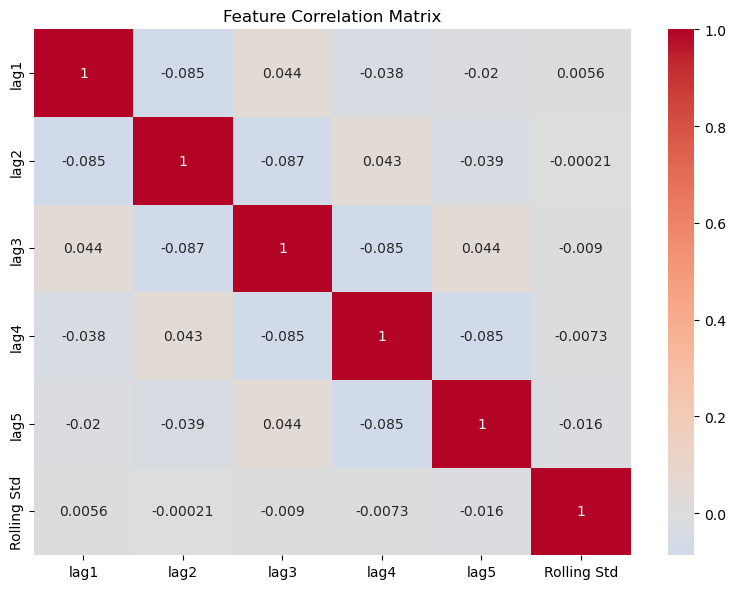

In [6]:
# Feature correlation analysis
plt.figure(figsize=(8, 6))
sns.heatmap(x.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

**Observation:** All features show low correlations (< 0.1), indicating they provide independent information. No feature elimination is needed — all 6 features will be retained for modeling.

## Train Test Split

Used a time based split to preserve the temporal order of the data:
- **Train:** 80% (2022 — 2024)
- **Test:** 20% (2024 — 2025)

Splitting both feature sets using time-based split (80/20).

Note: Random shuffling was avoided to prevent data leakage.

In [7]:
# Split for Random Forest
split = int(len(x) * 0.8)
x_train, x_test= x[:split], x[split:]
y_train, y_test= y[:split], y[split:]

# Split Validation Checks

In [8]:
print("VALIDATION CHECKS")

train=x
test=y


# CHECK 1: Split Ratio
print("\n✓ Check 2: Split Ratio")
total = len(train) + len(test)
train_pct = (len(train) / total) * 100
print(f"Train: {len(train)} ({train_pct:.1f}%)")
print(f"Test: {len(test)} ({100-train_pct:.1f}%)")

# CHECK 2: Feature Shapes
print("\n Check 3: Feature Shapes")
print(f"X_train: {x_train.shape}")
print(f"X_test: {x_test.shape}")
if x_train.shape[1] == x_test.shape[1]:
    print(f"Both have {x_train.shape[1]} features")


VALIDATION CHECKS

✓ Check 2: Split Ratio
Train: 1984 (50.0%)
Test: 1984 (50.0%)

 Check 3: Feature Shapes
X_train: (1587, 6)
X_test: (397, 6)
Both have 6 features


## Model Training

Training the Linear Regression model on the training data.

In [9]:
LR=LinearRegression()
LR.fit(x_train,y_train)

LinearRegression()

## Model Prediction

In [10]:
y_pred=LR.predict(x_test)

# Model Evaluation

In [11]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse=np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"RMSE : {rmse:6f}")
print(f"R2 Score: {r2:.4f}")

MSE: 0.000998
MAE: 0.022794
RMSE : 0.031587
R2 Score: 0.0149


## Actual vs Predicted Plot

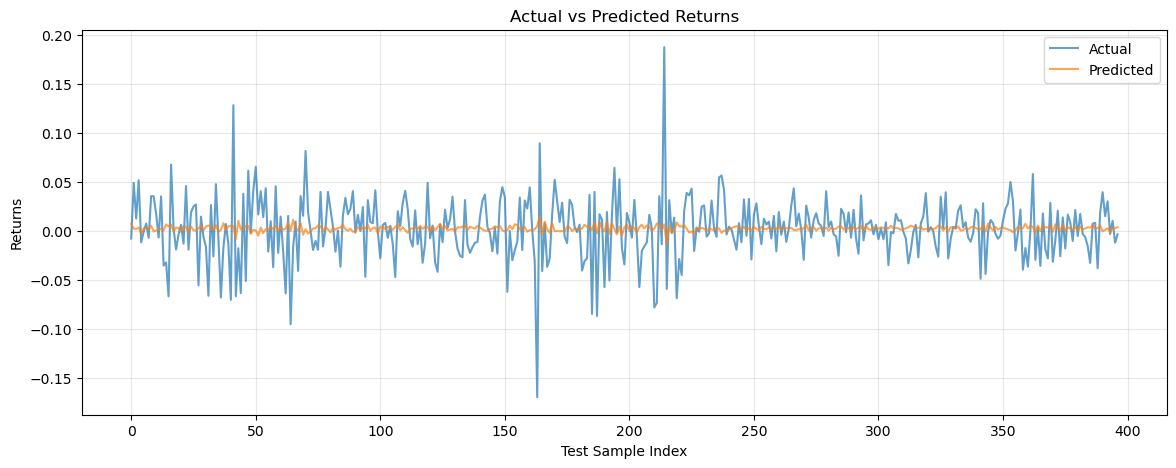

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.values, label='Actual', alpha=0.7)
plt.plot(y_pred, label='Predicted', alpha=0.7)
plt.title('Actual vs Predicted Returns')
plt.xlabel('Test Sample Index')
plt.ylabel('Returns')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

##### Visualizing model predictions against actual returns to assess how well the model captures return patterns and volatility. The predicted line (orange) shows the model's forecast, while the actual line (blue) represents true market movements. A close alignment between the two indicates accurate predictions.

## Residual Analysis

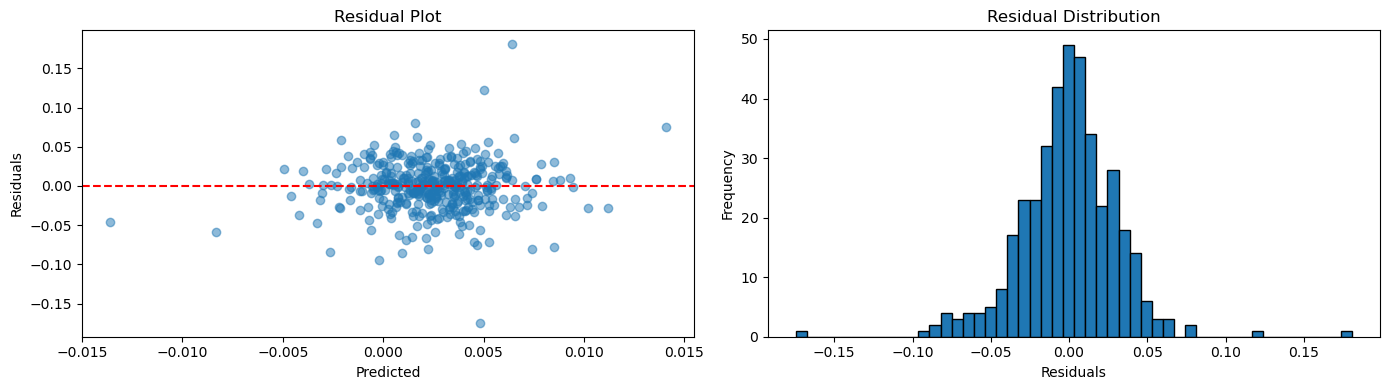

In [13]:
# Calculate residuals
residuals = y_test - y_pred

# Plot residuals
plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=50, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.tight_layout()
plt.show()

##### Examining prediction errors (residuals = actual - predicted) to assess model assumptions and identify patterns in errors. The residual plot (left) checks for systematic bias—ideally, points should scatter randomly around zero with no clear pattern. The distribution (right) shows the spread of errors; a bell-shaped curve centered at zero indicates unbiased predictions with normally distributed errors.

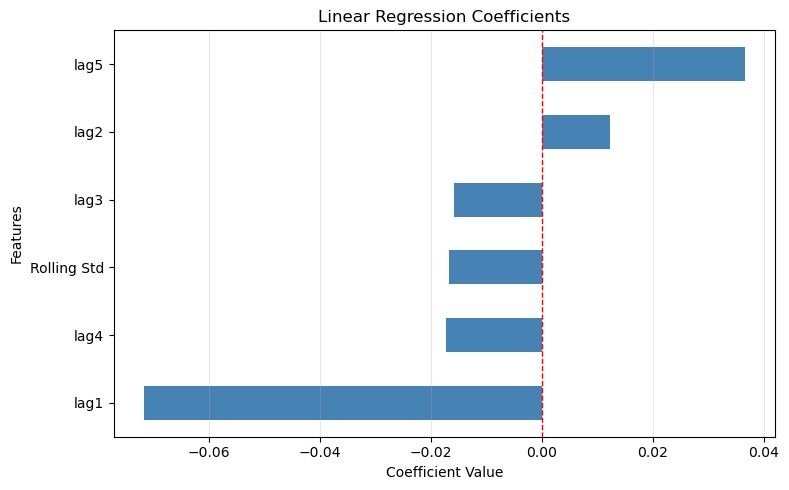

In [14]:
# Coefficients
coefficients = pd.Series(LR.coef_, index=x_train.columns)
plt.figure(figsize=(8, 5))
coefficients.sort_values().plot(kind='barh', color='steelblue')
plt.title('Linear Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Linear Regression — Results Summary

**Model Performance:**
- MSE: 0.000998
- RMSE: 0.031587
- MAE: 0.022794
- R² Score: 0.0149

**Key Observations:**
- Linear Regression achieved a **positive R² score (0.0149)**, indicating it performs slightly better than predicting the mean return
- The model shows relatively **unbiased predictions** with residuals roughly centered around zero, though significant spread remains due to market volatility
- **Coefficient analysis** reveals weak linear relationships between lag features and future returns, with no single lag dominating the prediction
- Residual analysis confirms the model captures minimal variance, as expected when predicting highly noisy financial returns

**Performance Context:**
Linear Regression serves as the simplest machine learning baseline. The low but positive R² (1.49%) demonstrates that even basic linear patterns provide marginal predictive value in daily stock returns. The model's inability to explain more variance reflects the fundamental challenge of financial prediction—daily returns are largely driven by unpredictable market events rather than historical patterns.